In [1]:
import gymnasium as gym
from stable_baselines3 import PPO

env = gym.make("CartPole-v1")

model = PPO(policy="MlpPolicy", env=env, verbose=1)

model.learn(total_timesteps=100)

model.save("ppo_cartpole")

env.close()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.5     |
|    ep_rew_mean     | 22.5     |
| time/              |          |
|    fps             | 1707     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


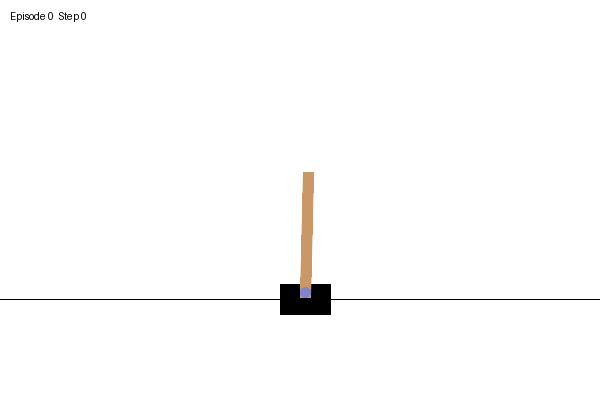

In [4]:
import gymnasium as gym
from stable_baselines3 import PPO
from PIL import Image, ImageDraw
import numpy as np
import imageio.v2 as imageio
from IPython.display import Image as IPImage


env = gym.make("CartPole-v1", render_mode="rgb_array")
model = PPO.load("ppo_cartpole")

frames = []
obs, _ = env.reset()
episode = 0

for step in range(300):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)

    frame = env.render()

    pil_img = Image.fromarray(frame)
    draw = ImageDraw.Draw(pil_img)
    draw.text((10, 10), f"Episode {episode}  Step {step}", fill=(0, 0, 0))
    frames.append(np.array(pil_img))

    if terminated or truncated:
        episode += 1
        obs, _ = env.reset()

env.close()

imageio.mimsave("LearningVisualization/tmp.gif", frames, fps=10)

IPImage(filename="LearningVisualization/tmp.gif")